In [ ]:
# 1. Import Libraries
# 2. Load Dataset
# 3. Data Exploration
# 4. Category Distribution
# 5. Text Cleaning
# 6. TF-IDF Vectorization
# 7. Train-Test Split
# 8. Logistic Regression Model
# 9. Linear SVM Model
# 10. Model Comparison
# 11. Confusion Matrix
# 12. Priority Prediction
# 13. Save Model
# 14. Demo Prediction
# 15. Conclusion

In [ ]:
import pandas as pd
X_train = pd.read_csv('../data/zenodo_dataset/X_train.csv')
X_test = pd.read_csv('../data/zenodo_dataset/X_test.csv')

y_train = pd.read_csv('../data/zenodo_dataset/y_train.csv')
y_test = pd.read_csv('../data/zenodo_dataset/y_test.csv')

In [87]:
print(X_train.head())
print(X_train.shape)

     id  \
0  1919   
1  1584   
2   584   
3  1393   
4  8636   

                                                                                                                                                        text  
0                                                                                   File Share Access - [TICKET ID] - [NAME]. [NAME] ([COMPANY]. [LOCATION])  
1                                                                                          File Share Access - [TICKET ID] - [NAME] ([COMPANY]A. [LOCATION])  
2                               [TICKET ID] - A Support Ticket was forwarded to your role  - Leaving Employee - [TICKET ID] - [NAME] ([COMPANY]. [LOCATION])  
3  [TICKET ID] - A Support Ticket was forwarded to your role  - check_mk SD Hostalarm: ([LOCATION]-WSUS01) [COMPANY] [SERVER] -[LOCATION]Server - UP -> DOWN  
4                                                                                       LVS not respondingLVS will not except my password 

In [88]:
print(y_train.head())
print(y_train.shape)

     id   category_truth
0  1919      Fileservice
1  1584      Fileservice
2   584  Support general
3  1393  Support general
4  8636      Fileservice
(1572, 2)


In [2]:
import pandas as pd
X_train = pd.read_csv("../data/X_train.csv")
y_train = pd.read_csv("../data/y_train.csv")

df = pd.merge(X_train, y_train, on="id")

df.head()

,id,text,category_truth
0,1919,File Share Access - [TICKET ID] - [NAME]. [NAM...,Fileservice
1,1584,File Share Access - [TICKET ID] - [NAME] ([COM...,Fileservice
2,584,[TICKET ID] - A Support Ticket was forwarded t...,Support general
3,1393,[TICKET ID] - A Support Ticket was forwarded t...,Support general
4,8636,LVS not respondingLVS will not except my passw...,Fileservice


In [3]:
print(df.columns)

Index(['id', 'text', 'category_truth'], dtype='object')


In [4]:
print(X_train.shape)
print(y_train.shape)

print(X_train.columns)
print(y_train.columns)

df = pd.merge(X_train, y_train, on="id")

print(df.shape)
df.head()

(1572, 2)
(1572, 2)
Index(['id', 'text'], dtype='object')
Index(['id', 'category_truth'], dtype='object')
(1572, 3)


,id,text,category_truth
0,1919,File Share Access - [TICKET ID] - [NAME]. [NAM...,Fileservice
1,1584,File Share Access - [TICKET ID] - [NAME] ([COM...,Fileservice
2,584,[TICKET ID] - A Support Ticket was forwarded t...,Support general
3,1393,[TICKET ID] - A Support Ticket was forwarded t...,Support general
4,8636,LVS not respondingLVS will not except my passw...,Fileservice


In [5]:
print(df.isnull().sum())

id                0
text              0
category_truth    0
dtype: int64


category_truth
Fileservice          546
Support general      541
Software             164
O365                 127
Active Directory      84
Computer-Services     65
EOL                   45
Name: count, dtype: int64


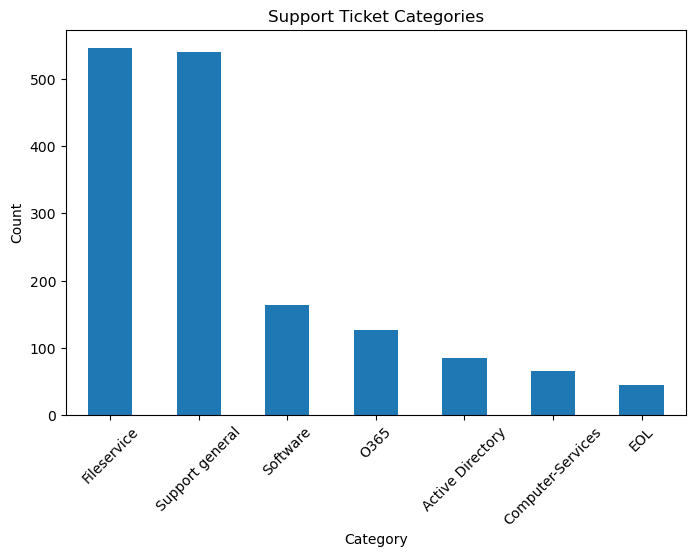

In [6]:
import matplotlib.pyplot as plt

category_counts = df["category_truth"].value_counts()

print(category_counts)

plt.figure(figsize=(8,5))
category_counts.plot(kind="bar")
plt.title("Support Ticket Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [7]:
df["text_length"] = df["text"].astype(str).apply(len)

print(df["text_length"].describe())

count    1572.000000
mean      130.627226
std       183.412468
min         8.000000
25%        50.000000
50%        65.000000
75%        92.000000
max      1763.000000
Name: text_length, dtype: float64


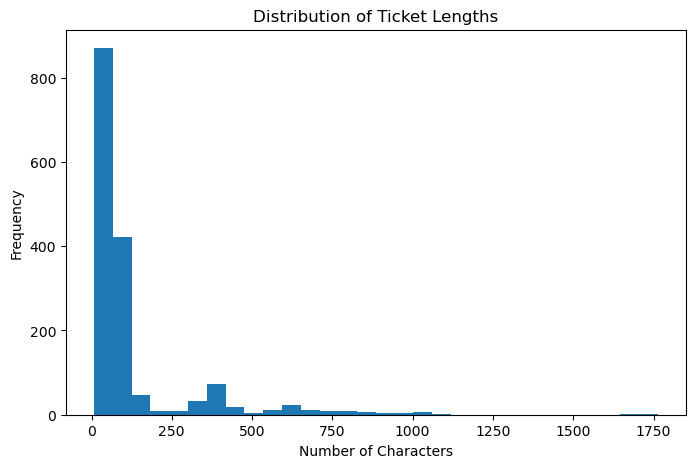

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df["text_length"], bins=30)
plt.title("Distribution of Ticket Lengths")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.show()

In [9]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df["clean_text"] = df["text"].apply(clean_text)

df[["text","clean_text"]].head()

,text,clean_text
0,File Share Access - [TICKET ID] - [NAME]. [NAM...,file share access ticket id name name company ...
1,File Share Access - [TICKET ID] - [NAME] ([COM...,file share access ticket id name company a loc...
2,[TICKET ID] - A Support Ticket was forwarded t...,ticket id a support ticket was forwarded to yo...
3,[TICKET ID] - A Support Ticket was forwarded t...,ticket id a support ticket was forwarded to yo...
4,LVS not respondingLVS will not except my passw...,lvs not respondinglvs will not except my passw...


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X = vectorizer.fit_transform(df["clean_text"])
y = df["category_truth"]

print(X.shape)

(1572, 2124)


In [11]:
from sklearn.model_selection import train_test_split

X_train_tfidf, X_test_tfidf, y_train_lbl, y_test_lbl = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(X_train_tfidf, y_train_lbl)

pred_lr = lr_model.predict(X_test_tfidf)

In [13]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

print("Accuracy:",
      accuracy_score(y_test_lbl, pred_lr))

print(classification_report(
    y_test_lbl,
    pred_lr
))

Accuracy: 0.7777777777777778
                   precision    recall  f1-score   support

 Active Directory       0.80      0.24      0.36        17
Computer-Services       1.00      0.62      0.76        13
              EOL       1.00      1.00      1.00         9
      Fileservice       0.95      0.90      0.92       109
             O365       0.55      0.23      0.32        26
         Software       1.00      0.42      0.60        33
  Support general       0.64      0.98      0.78       108

         accuracy                           0.78       315
        macro avg       0.85      0.63      0.68       315
     weighted avg       0.81      0.78      0.75       315



In [14]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train_lbl)

pred_svm = svm_model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test_lbl, pred_svm))

print(classification_report(
    y_test_lbl,
    pred_svm
))

Accuracy: 0.7968253968253968
                   precision    recall  f1-score   support

 Active Directory       0.55      0.35      0.43        17
Computer-Services       1.00      0.69      0.82        13
              EOL       1.00      1.00      1.00         9
      Fileservice       0.96      0.94      0.95       109
             O365       0.50      0.46      0.48        26
         Software       0.81      0.52      0.63        33
  Support general       0.71      0.89      0.79       108

         accuracy                           0.80       315
        macro avg       0.79      0.69      0.73       315
     weighted avg       0.80      0.80      0.79       315



<Figure size 1000x800 with 0 Axes>

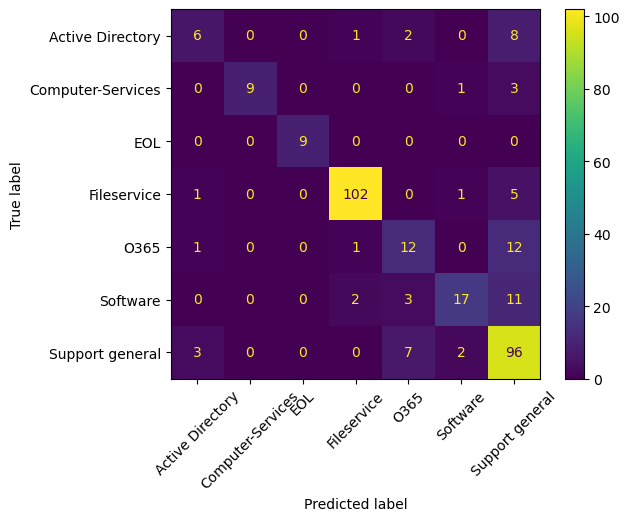

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

ConfusionMatrixDisplay.from_predictions(
    y_test_lbl,
    pred_svm,
    xticks_rotation=45
)

plt.show()

In [19]:
import joblib

joblib.dump(
    svm_model,
    "../models/support_ticket_classifier.pkl"
)

joblib.dump(
    vectorizer,
    "../models/tfidf_vectorizer.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [20]:
def assign_priority(text):

    text = text.lower()

    high_keywords = [
        "urgent",
        "critical",
        "down",
        "outage",
        "security",
        "failed"
    ]

    medium_keywords = [
        "error",
        "issue",
        "problem",
        "slow"
    ]

    if any(word in text for word in high_keywords):
        return "High"

    elif any(word in text for word in medium_keywords):
        return "Medium"

    return "Low"

In [21]:
ticket = "Urgent outage in file server"

category = svm_model.predict(
    vectorizer.transform([ticket])
)[0]

priority = assign_priority(ticket)

print("Ticket:", ticket)
print("Predicted Category:", category)
print("Predicted Priority:", priority)

Ticket: Urgent outage in file server
Predicted Category: Fileservice
Predicted Priority: High
